# Classification decision tree

In [10]:
import pandas as pd

penguins = pd.read_csv('data/penguins_classification.csv')
culmen_columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]
target_column = "Species"
penguins.head()

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
3,36.7,19.3,Adelie
4,39.3,20.6,Adelie


In [13]:
from sklearn.model_selection import train_test_split
data, target = penguins[culmen_columns], penguins[target_column]
data_train, data_test, target_train, target_test = train_test_split(data, target, random_state=0)

In [14]:
from sklearn.linear_model import LogisticRegression

linear_model = LogisticRegression()
linear_model.fit(data_train, target_train)

LogisticRegression()

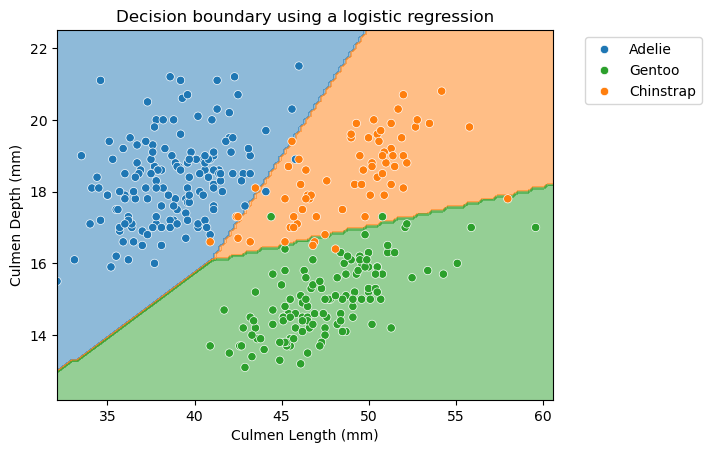

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.inspection import DecisionBoundaryDisplay

tab10_norm = mpl.colors.Normalize(vmin=-0.5, vmax=8.5)
# create a palette to be used in the scatterplot
palette = ["tab:blue", "tab:green", "tab:orange"]

dbd = DecisionBoundaryDisplay.from_estimator(
    linear_model,
    data_train,
    response_method="predict",
    cmap="tab10",
    norm=tab10_norm,
    alpha=0.5,
)
sns.scatterplot(
    data=penguins,
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column,
    palette=palette,
)
# put the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
_ = plt.title("Decision boundary using a logistic regression")

In [18]:
linear_model.fit(data_train, target_train)
test_score = linear_model.score(data_test, target_test)
print(f"Accuracy of the LogisticRegression: {test_score:.2f}")

Accuracy of the LogisticRegression: 0.98


- In linear models the decision tree is controlled by linear combination of weights and feature variables
- In decision tree, decision rule is defined in terms of : 
    - the feature index used at each split node of the tree,
    - the threshold value used at each split node,
    - the value to predict at each leaf node. 

- Decision trees partition the feature space by considering a single feature at a time. The number of splits depends on both the hyperparameters and the number of data points in the training set: the more flexible the hyperparameters and the larger the training set, the more splits can be considered by the model.

- As the number of adjustable components taking part in the decision rule changes with the training size, we say that decision trees are non-parametric models.

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=1)
tree.fit(data_train, target_train)

DecisionTreeClassifier(max_depth=1)

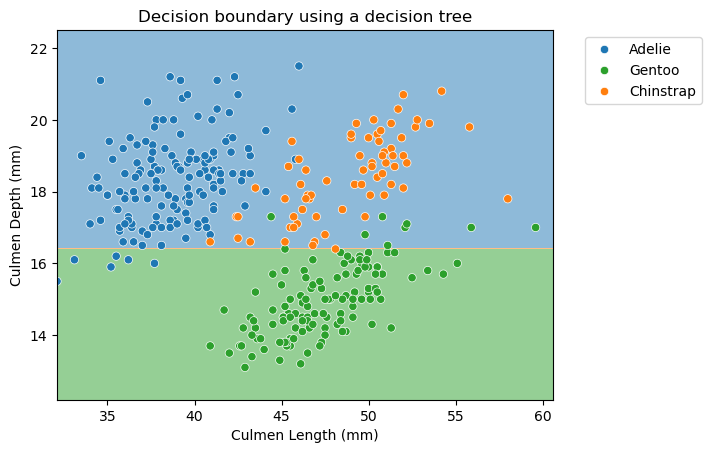

In [20]:
DecisionBoundaryDisplay.from_estimator(
    tree,
    data_train,
    response_method="predict",
    cmap="tab10",
    norm=tab10_norm,
    alpha=0.5,
)
sns.scatterplot(
    data=penguins,
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column,
    palette=palette,
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
_ = plt.title("Decision boundary using a decision tree")


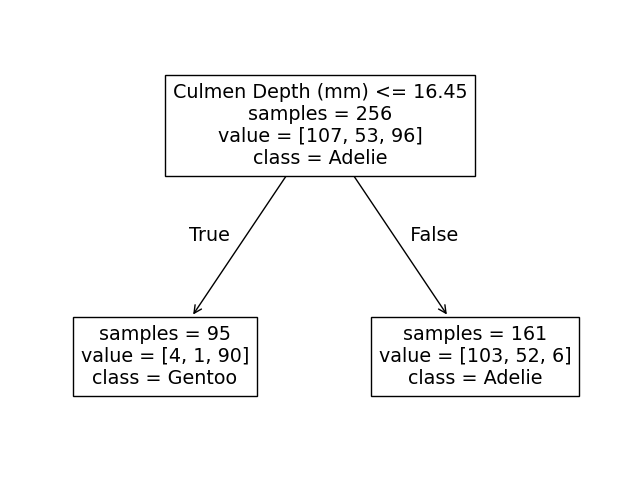

In [23]:
from sklearn.tree import plot_tree

_, ax = plt.subplots(figsize=(8, 6))
_ = plot_tree(
    tree,
    feature_names=culmen_columns,
    class_names=tree.classes_.tolist(),
    impurity=False,
    ax=ax,
)

- the split was done on the culmen depth feature. The original dataset was subdivided into 2 sets based on the culmen depth (inferior or superior to 16.45 mm).

In [24]:
test_penguin_1 = pd.DataFrame(
    {"Culmen Length (mm)": [0], "Culmen Depth (mm)": [15]} # culmen depth is inferior to the threshold.
)
tree.predict(test_penguin_1)

array(['Gentoo'], dtype=object)

In [25]:
test_penguin_2 = pd.DataFrame(
    {"Culmen Length (mm)": [0], "Culmen Depth (mm)": [17]} # culmen depth is superior to the threshold.
)
tree.predict(test_penguin_2)

array(['Adelie'], dtype=object)

In [26]:
y_pred_proba = tree.predict_proba(test_penguin_2)
y_proba_class_0 = pd.Series(y_pred_proba[0], index=tree.classes_)

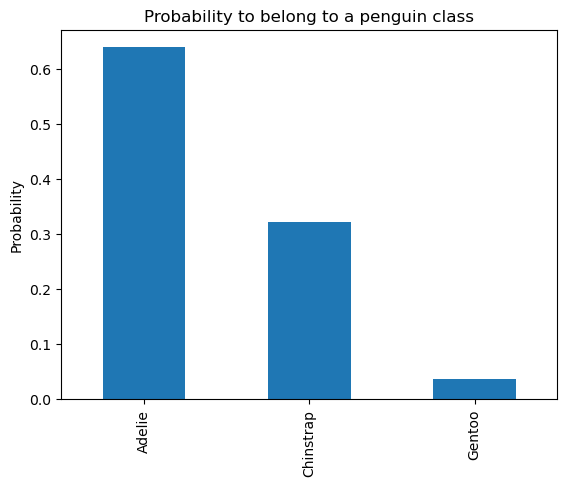

In [27]:
y_proba_class_0.plot.bar()
plt.ylabel("Probability")
_ = plt.title("Probability to belong to a penguin class")

In [28]:
adelie_proba = 103 / 161
chinstrap_proba = 52 / 161
gentoo_proba = 6 / 161
print(
    "Probabilities for the different classes:\n"
    f"Adelie: {adelie_proba:.3f}\n"
    f"Chinstrap: {chinstrap_proba:.3f}\n"
    f"Gentoo: {gentoo_proba:.3f}\n"
)

Probabilities for the different classes:
Adelie: 0.640
Chinstrap: 0.323
Gentoo: 0.037



In [29]:
test_penguin_3 = pd.DataFrame(
    {"Culmen Length (mm)": [10_000], "Culmen Depth (mm)": [17]}
)
tree.predict_proba(test_penguin_3)

array([[0.63975155, 0.32298137, 0.03726708]])

In [30]:
tree.fit(data_train, target_train)
test_score = tree.score(data_test, target_test)
print(f"Accuracy of the DecisionTreeClassifier: {test_score:.2f}")

Accuracy of the DecisionTreeClassifier: 0.78


- Max depth = 2


In [31]:
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(data_train, target_train)

DecisionTreeClassifier(max_depth=2)

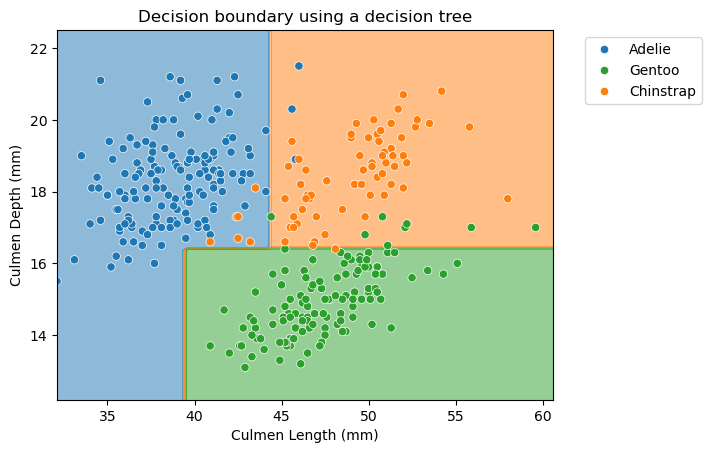

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.inspection import DecisionBoundaryDisplay


tab10_norm = mpl.colors.Normalize(vmin=-0.5, vmax=8.5)

palette = ["tab:blue", "tab:green", "tab:orange"]
DecisionBoundaryDisplay.from_estimator(
    tree,
    data_train,
    response_method="predict",
    cmap="tab10",
    norm=tab10_norm,
    alpha=0.5,
)
ax = sns.scatterplot(
    data=penguins,
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column,
    palette=palette,
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
_ = plt.title("Decision boundary using a decision tree")

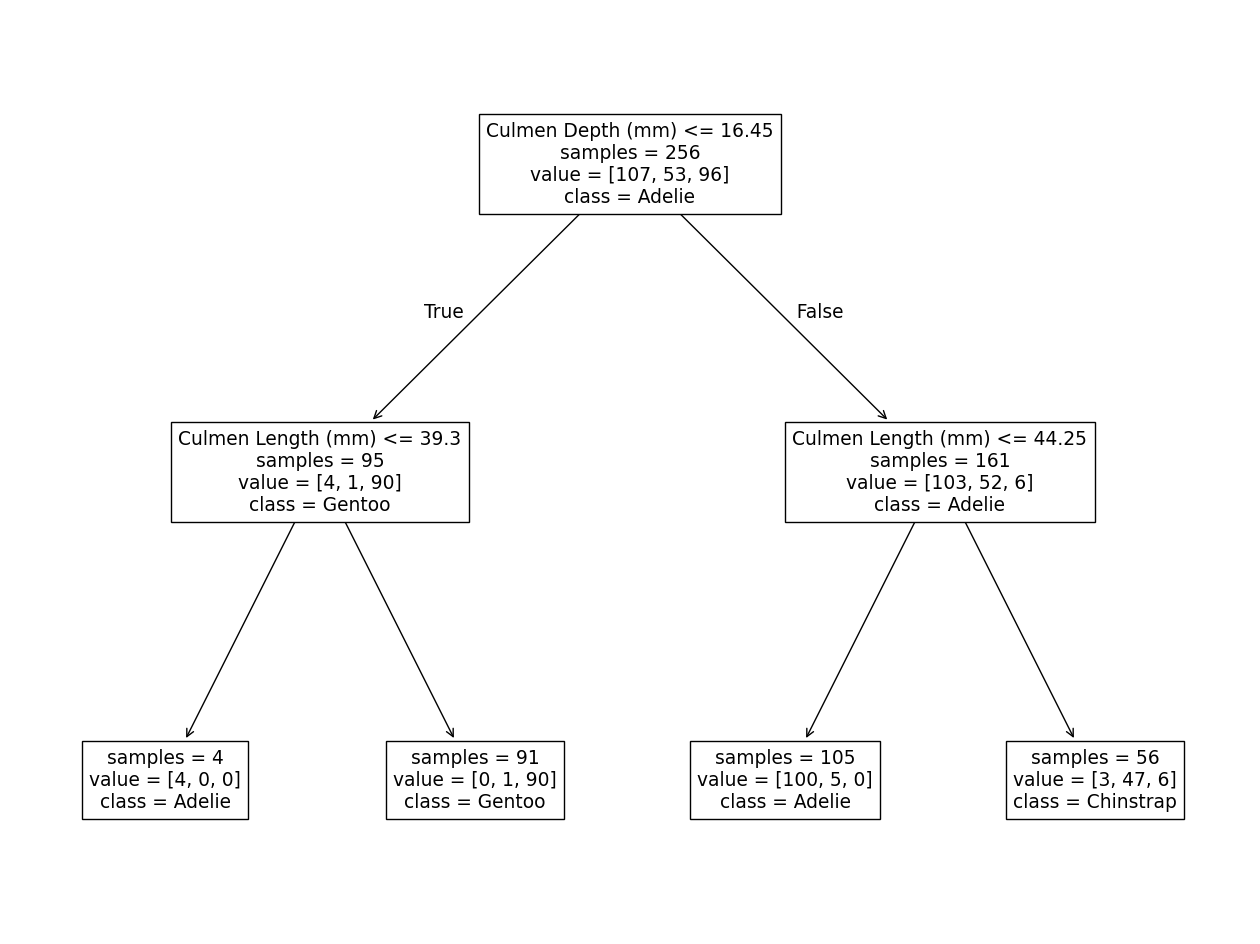

In [33]:
from sklearn.tree import plot_tree

_, ax = plt.subplots(figsize=(16, 12))
_ = plot_tree(
    tree,
    feature_names=culmen_columns,
    class_names=tree.classes_.tolist(),
    impurity=False,
    ax=ax,
)

In [34]:
test_score = tree.fit(data_train, target_train).score(data_test, target_test)
print(f"Accuracy of the DecisionTreeClassifier: {test_score:.2f}")

Accuracy of the DecisionTreeClassifier: 0.97


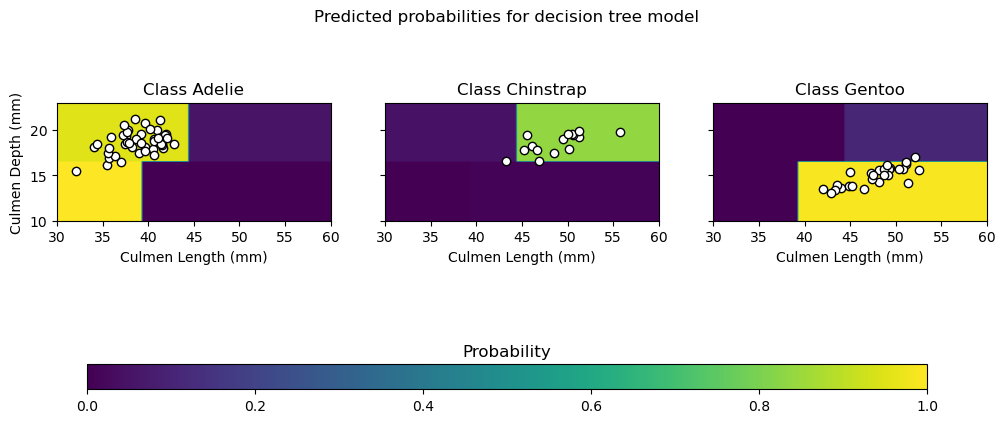

In [35]:
import numpy as np

xx = np.linspace(30, 60, 100)
yy = np.linspace(10, 23, 100)
xx, yy = np.meshgrid(xx, yy)
Xfull = pd.DataFrame(
    {"Culmen Length (mm)": xx.ravel(), "Culmen Depth (mm)": yy.ravel()}
)

probas = tree.predict_proba(Xfull)
n_classes = len(np.unique(tree.classes_))

_, axs = plt.subplots(ncols=3, nrows=1, sharey=True, figsize=(12, 5))
plt.suptitle("Predicted probabilities for decision tree model", y=0.8)

for class_of_interest in range(n_classes):
    axs[class_of_interest].set_title(
        f"Class {tree.classes_[class_of_interest]}"
    )
    imshow_handle = axs[class_of_interest].imshow(
        probas[:, class_of_interest].reshape((100, 100)),
        extent=(30, 60, 10, 23),
        vmin=0.0,
        vmax=1.0,
        origin="lower",
        cmap="viridis",
    )
    axs[class_of_interest].set_xlabel("Culmen Length (mm)")
    if class_of_interest == 0:
        axs[class_of_interest].set_ylabel("Culmen Depth (mm)")
    idx = target_test == tree.classes_[class_of_interest]
    axs[class_of_interest].scatter(
        data_test["Culmen Length (mm)"].loc[idx],
        data_test["Culmen Depth (mm)"].loc[idx],
        marker="o",
        c="w",
        edgecolor="k",
    )

ax = plt.axes([0.15, 0.04, 0.7, 0.05])
plt.colorbar(imshow_handle, cax=ax, orientation="horizontal")
_ = plt.title("Probability")